# Regressions on monthly data


In [100]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.api import VAR
from statsmodels.genmod.families import NegativeBinomial
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('../data/intermediate/monthly.csv')
df = df.drop(columns=["Unnamed: 0"])

count_vars = [
    "total", "pmc", "prisoners", "drafted", "volunteers", "contract",
    "slavic_name", "non_slavic_name"
]

df[count_vars] = df[count_vars].fillna(0)
df['log_pop'] = np.log(df['population'])
df['post'] = (df['Date'] >= '2022-09').astype(int)
df["log_inc"] = np.log(df['median_income'])
df["total_per100k"] = df["total"]/df['population']*100_000
df["pmc_per100k"] = df["pmc"]/df['population']*100_000
df["prisoners_per100k"] = df["prisoners"]/df['population']*100_000
df["drafted_per100k"] = df["drafted"]/df['population']*100_000
df["volunteers_per100k"] = df["volunteers"]/df['population']*100_000
df["contract_per100k"] = df["contract"]/df['population']*100_000
df['nup'] = df['post'] * df['ex_nup_per100k']
df["slavic_per100k"] = df["slavic_name"]/df['population']*100_000
df["non_slavic_per100k"] = df["non_slavic_name"]/df['population']*100_000


df['conc_fat'] = df.groupby('Date')['total'].transform(
    lambda x: 100 * (x / x.sum()) if x.sum() != 0 else 0)
df['conc_pop'] = df.groupby('Date')['population'].transform(
    lambda x: 100 * (x / x.sum()) if x.sum() != 0 else 0)
df['rel_risk'] = df['conc_fat']/df['conc_pop']


C:\Users\Albert\AppData\Local\Temp\ipykernel_9028\1434733474.py:20: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['deposit_growth_pct'] = df.groupby('Region')['Deposits'].pct_change() * 100
C:\Users\Albert\AppData\Local\Temp\ipykernel_9028\1434733474.py:22: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['deposit_yoy_pct'] = df.groupby(['Region'])['Deposits'].pct_change(periods=12) * 100


# Deposits

In [131]:
deps = df[['Region', 'Date', 'Deposits', 'total']]
ru_dep = deps.groupby('Date')[['Deposits', 'total']].sum().reset_index()
ru_dep['cumulative_fatalities'] = ru_dep['total'].cumsum()
ru_dep['dep_bln'] = ru_dep['Deposits']/1_000
ru_dep = ru_dep[ru_dep['Date'] < '2025-01-01']
ru_dep[["dep_bln", 'total']].corr()

,dep_bln,total
dep_bln,1.000000,0.665944
total,0.665944,1.000000


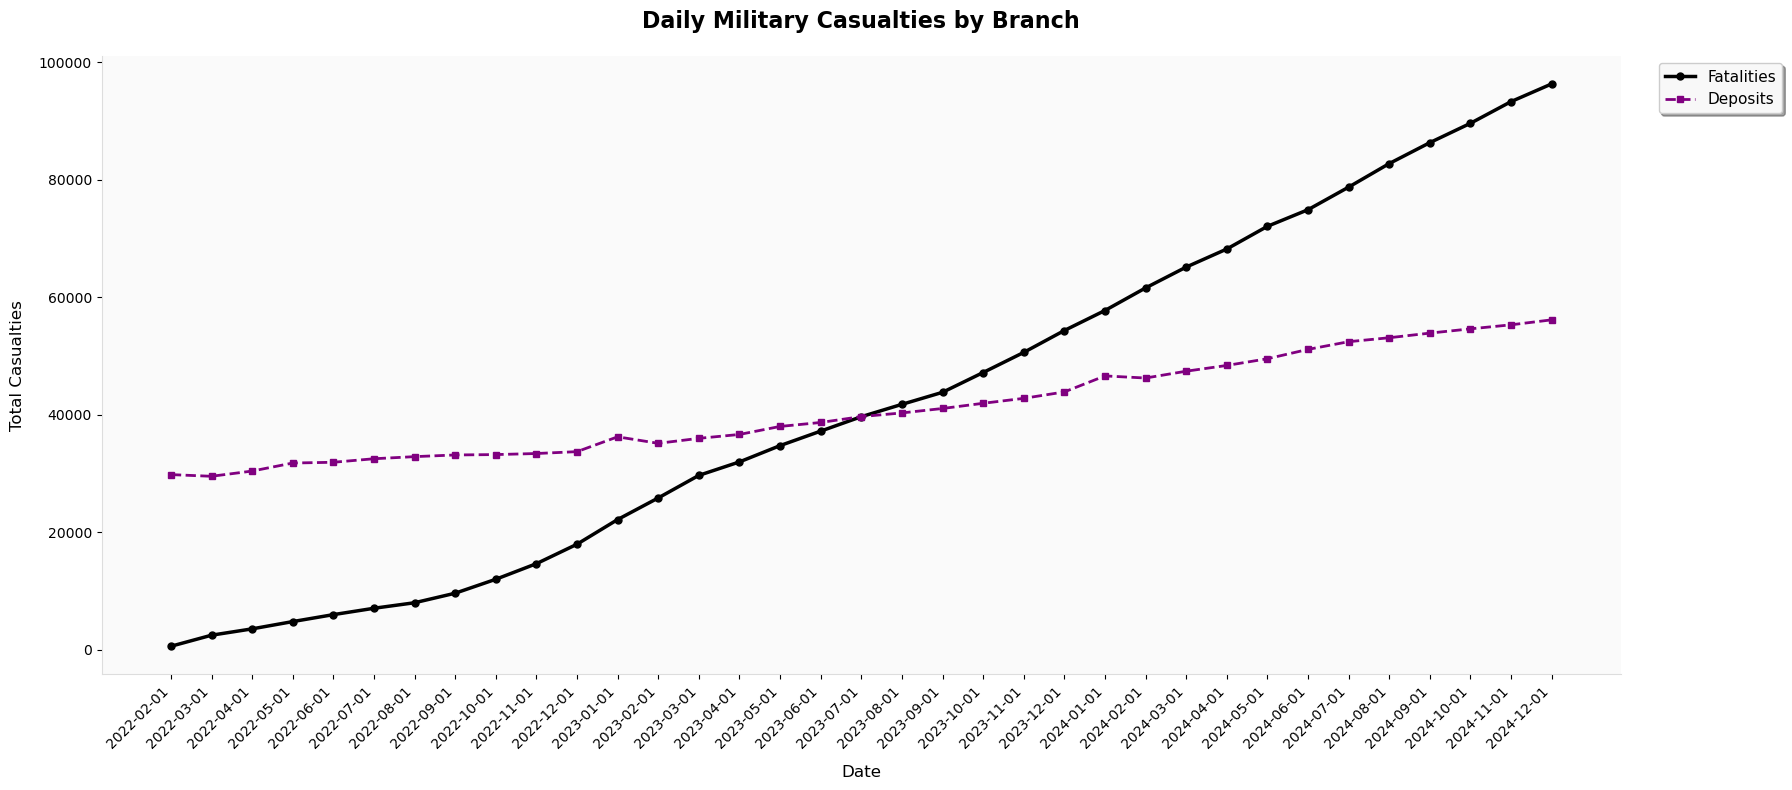

In [133]:

plt.figure(figsize=(18, 8))


plt.plot(
    ru_dep['Date'],
    ru_dep['cumulative_fatalities'],
    color='#000000',
    linestyle='-',
    linewidth=2.5,
    marker='o',
    markersize=5,
    label='Fatalities',
    zorder=3  # Keep above bars
)

plt.plot(
    ru_dep['Date'],
    ru_dep['dep_bln'],
    color='#800080',
    linestyle='--',
    linewidth=2,
    marker='s',
    markersize=4,
    label='Deposits',
    zorder=3
)

# Add styling elements
plt.title('Daily Military Casualties by Branch', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Total Casualties', fontsize=12, labelpad=10)

plt.legend(
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    shadow=True,
    fancybox=True,
    facecolor='#f8f8f8',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#dddddd')
plt.gca().spines['bottom'].set_color('#dddddd')

# Format date labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add light background
plt.gca().set_facecolor('#fafafa')

# Add subtle watermark
plt.figtext(0.5, 0.5, '', 
            ha='center', va='center', 
            fontsize=60, color='#f0f0f0', 
            alpha=0.3, zorder=-1)

plt.tight_layout()
plt.show()

## Insider Governor

In [94]:
df_model = df[['Region','Date','total', 'volunteers', 'drafted', 'pmc', 'prisoners', 'contract',
                'total_per100k', 'volunteers_per100k', 'drafted_per100k', 'pmc_per100k', 'prisoners_per100k', 'contract_per100k',
                'nup','insider', 'rel_risk']].copy()

df_model = df_model.dropna()  
df_model

,Region,Date,total,volunteers,drafted,pmc,prisoners,contract,total_per100k,volunteers_per100k,drafted_per100k,pmc_per100k,prisoners_per100k,contract_per100k,nup,insider,rel_risk
0,Алтайский край,2022-02-01,1.0,0.0,0.0,0.0,0.0,1.0,0.046666,0.000000,0.0,0.0,0.0,0.046666,0.0000,0.0,0.111734
1,Алтайский край,2022-03-01,35.0,0.0,0.0,0.0,0.0,35.0,1.633301,0.000000,0.0,0.0,0.0,1.633301,0.0000,0.0,1.245446
2,Алтайский край,2022-04-01,32.0,2.0,0.0,0.0,0.0,30.0,1.493303,0.093331,0.0,0.0,0.0,1.399972,0.0000,0.0,1.990073
3,Алтайский край,2022-05-01,62.0,2.0,0.0,0.0,0.0,60.0,2.893275,0.093331,0.0,0.0,0.0,2.799944,0.0000,0.0,3.352030
4,Алтайский край,2022-06-01,34.0,4.0,0.0,0.0,0.0,30.0,1.586635,0.186663,0.0,0.0,0.0,1.399972,0.0000,0.0,1.930043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,5.0,0.0,0.0,0.0,0.0,1.0,0.416632,0.000000,0.0,0.0,0.0,0.083326,293.7311,1.0,0.621606
3551,Ярославская область,2025-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,293.7311,1.0,0.000000
3552,Ярославская область,2025-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,293.7311,1.0,0.000000
3553,Ярославская область,2025-06-01,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,293.7311,1.0,0.000000


In [96]:
model = smf.ols('rel_risk ~ nup + C(Date) + C(Region) + insider',
                 data=df_model).fit()
print(model.summary())
# overall negative effect - in break down significant only for volunteers: 

                            OLS Regression Results                            
Dep. Variable:               rel_risk   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     2.913
Date:                 Пн, 18 авг 2025   Prob (F-statistic):           1.78e-23
Time:                        07:42:55   Log-Likelihood:                -8801.5
No. Observations:                3471   AIC:                         1.786e+04
Df Residuals:                    3345   BIC:                         1.863e+04
Df Model:                         125                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [81]:
df_model = df[['Region','Date', 'nat_rep','drafted_per100k','nup','insider', 'uneployment', 'median_income','share_poverty', 'log_inc',
               '% Russians', 'log_pop']].copy()

df_model = df_model.dropna()  
df_model

,Region,Date,nat_rep,drafted_per100k,nup,insider,uneployment,median_income,share_poverty,log_inc,% Russians,log_pop
0,Алтайский край,2022-02-01,0.0,0.0,0.0000,0.0,3.7,24037.0,15.4,10.087350,95.45,14.577671
1,Алтайский край,2022-03-01,0.0,0.0,0.0000,0.0,3.7,24037.0,15.4,10.087350,95.45,14.577671
2,Алтайский край,2022-04-01,0.0,0.0,0.0000,0.0,3.7,24037.0,15.4,10.087350,95.45,14.577671
3,Алтайский край,2022-05-01,0.0,0.0,0.0000,0.0,3.7,24037.0,15.4,10.087350,95.45,14.577671
4,Алтайский край,2022-06-01,0.0,0.0,0.0000,0.0,3.7,24037.0,15.4,10.087350,95.45,14.577671
...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,0.0,0.0,293.7311,1.0,5.0,30524.1,8.8,10.326272,96.52,13.997915
3551,Ярославская область,2025-04-01,0.0,0.0,293.7311,1.0,5.0,30524.1,8.8,10.326272,96.52,13.997915
3552,Ярославская область,2025-05-01,0.0,0.0,293.7311,1.0,5.0,30524.1,8.8,10.326272,96.52,13.997915
3553,Ярославская область,2025-06-01,0.0,0.0,293.7311,1.0,5.0,30524.1,8.8,10.326272,96.52,13.997915


In [84]:
model = smf.ols('drafted_per100k ~ nup + C(Date) + share_poverty + insider + nat_rep + Q("% Russians") + log_pop + log_inc ',
                 data=df_model).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        drafted_per100k   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     7.720
Date:                 Пн, 18 авг 2025   Prob (F-statistic):           2.79e-48
Time:                        07:13:11   Log-Likelihood:                -3656.5
No. Observations:                3471   AIC:                             7411.
Df Residuals:                    3422   BIC:                             7712.
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.20

In [82]:
model = smf.ols('volunteers_per100k ~  C(Date) + C(Region) + insider + nup',
                 data=df_model).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     volunteers_per100k   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     7.834
Date:                 Сб, 16 авг 2025   Prob (F-statistic):          1.03e-112
Time:                        15:16:56   Log-Likelihood:                -5425.9
No. Observations:                3471   AIC:                         1.110e+04
Df Residuals:                    3345   BIC:                         1.188e+04
Df Model:                         125                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [87]:
model = smf.ols('drafted_per100k ~  C(Date) + C(Region) + insider + nup',
                 data=df_model[df_model['Date'] > '2023-12']).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        drafted_per100k   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     5.065
Date:                 Сб, 16 авг 2025   Prob (F-statistic):           6.48e-47
Time:                        15:20:14   Log-Likelihood:                -949.12
No. Observations:                1660   AIC:                             2104.
Df Residuals:                    1557   BIC:                             2662.
Df Model:                         102                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [93]:
nb_model = smf.glm(
    formula="pmc_per100k ~  nup + C(Date) + C(Region) + insider",
    data=df_model,
    family=NegativeBinomial()).fit()

print(nb_model.summary())


c:\Users\Albert\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:            pmc_per100k   No. Observations:                 3471
Model:                            GLM   Df Residuals:                     3345
Model Family:        NegativeBinomial   Df Model:                          125
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -488.95
Date:                 Сб, 16 авг 2025   Deviance:                       452.82
Time:                        15:21:57   Pearson chi2:                 1.57e+03
No. Iterations:                    23   Pseudo R-squ. (CS):            0.07857
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [ ]:
nb_model_b_rep = smf.glm(
    formula="total_per100k ~ nat_rep + post + post_x_rep + share_poverty + insider",
    data=df_model,
    family=NegativeBinomial()).fit()
nb_model_nup_rep = smf.glm(
    formula="total_per100k ~ nat_rep + nup + nup_x_rep + share_poverty + insider",
    data=df_model,
    family=NegativeBinomial()).fit()
nb_model_b_ins = smf.glm(
    formula="total_per100k ~ post + insider + post_x_ins + share_poverty + nat_rep",
    data=df_model,
    family=NegativeBinomial()).fit()
nb_model_nup_ins = smf.glm(
    formula="total_per100k ~ nup + insider + nup_x_ins + share_poverty + nat_rep",
    data=df_model,
    family=NegativeBinomial()).fit()
nb_model_b_pov = smf.glm(
    formula="total_per100k ~ post + share_poverty + post_x_pov + insider + nat_rep ",
    data=df_model,
    family=NegativeBinomial()).fit()
nb_model_nup_pov = smf.glm(
    formula="total_per100k ~ nup + share_poverty + nup_x_pov + insider + nat_rep ",
    data=df_model,
    family=NegativeBinomial()).fit()


c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value

## Conscripts

In [27]:
df_model = df[['Region','Date','drafted_per100k', 'post', 'ex_nup_per100k', 'nup', 'share_poverty', '% Russians',
               'median_income', 'uneployment', 'urban_share', 'population',
               'insider', 'nat_rep']].copy()
df_model['post_x_rep'] = df['post'] * df['nat_rep']
df_model['post_x_ins'] = df['post'] * df['insider']
df_model['post_x_pov'] = df['post'] * df['share_poverty']

df_model['nup_x_rep'] = df['nup'] * df['nat_rep']
df_model['nup_x_ins'] = df['nup'] * df['insider']
df_model['nup_x_pov'] = df['nup'] * df['share_poverty']

df_model = df_model.dropna()  
df_model

,Region,Date,drafted_per100k,post,ex_nup_per100k,nup,share_poverty,% Russians,median_income,uneployment,urban_share,population,insider,nat_rep,post_x_rep,post_x_ins,post_x_pov,nup_x_rep,nup_x_ins,nup_x_pov
0,Алтайский край,2022-02-01,0.0,0,343.285700,0.000000,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,Алтайский край,2022-03-01,0.0,0,343.285700,0.000000,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,Алтайский край,2022-04-01,0.0,0,343.285700,0.000000,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,Алтайский край,2022-05-01,0.0,0,343.285700,0.000000,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,Алтайский край,2022-06-01,0.0,0,343.285700,0.000000,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,0.0,1,232.629579,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,1.0,8.8,0.0,232.629579,2047.140297
3551,Ярославская область,2025-04-01,0.0,1,232.629579,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,1.0,8.8,0.0,232.629579,2047.140297
3552,Ярославская область,2025-05-01,0.0,1,232.629579,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,1.0,8.8,0.0,232.629579,2047.140297
3553,Ярославская область,2025-06-01,0.0,1,232.629579,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,1.0,8.8,0.0,232.629579,2047.140297


In [37]:
draft_b_rep = smf.glm(
    formula="drafted_per100k ~ nat_rep + post + post_x_rep + share_poverty + insider",
    data=df_model,
    family=NegativeBinomial()).fit()
draft_nup_rep = smf.glm(
    formula="drafted_per100k ~ nat_rep + nup + nup_x_rep + share_poverty + insider + C(Date)",
    data=df_model,
    family=NegativeBinomial()).fit()
draft_b_ins = smf.glm(
    formula="drafted_per100k ~ post + insider + post_x_ins + share_poverty + nat_rep",
    data=df_model,
    family=NegativeBinomial()).fit()
draft_nup_ins = smf.glm(
    formula="drafted_per100k ~ nup + insider + nup_x_ins + share_poverty + nat_rep + C(Date)",
    data=df_model,
    family=NegativeBinomial()).fit()
draft_b_pov = smf.glm(
    formula="drafted_per100k ~ post + share_poverty + post_x_pov + insider + nat_rep ",
    data=df_model,
    family=NegativeBinomial()).fit()
draft_nup_pov = smf.glm(
    formula="drafted_per100k ~ nup + share_poverty + nup_x_pov + insider + nat_rep  + C(Date)",
    data=df_model,
    family=NegativeBinomial()).fit()


c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value

In [38]:
print(draft_nup_pov.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        drafted_per100k   No. Observations:                 3555
Model:                            GLM   Df Residuals:                     3508
Model Family:        NegativeBinomial   Df Model:                           46
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1866.0
Date:                 Ср, 06 авг 2025   Deviance:                       1500.3
Time:                        00:17:16   Pearson chi2:                 2.95e+03
No. Iterations:                    24   Pseudo R-squ. (CS):             0.1725
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -25.75

## Raw count data: slavic

In [96]:
df_model = df[['Region', 'Date','slavic_per100k', 'post', 'ex_nup_per100k', 'share_poverty', '% Russians',
               'median_income', 'uneployment', 'urban_share', 'population',
               'insider', 'nat_rep']].copy()
df_model['post_x_rep'] = df['post'] * df['nat_rep']
df_model['post_x_pov'] = df['post'] * df['share_poverty']
df_model['post_x_ins'] = df['post'] * df['insider']
df_model = df_model.dropna()  
df_model

,Region,Date,slavic_per100k,post,ex_nup_per100k,share_poverty,% Russians,median_income,uneployment,urban_share,population,insider,nat_rep,post_x_rep,post_x_pov,post_x_ins
0,Алтайский край,2022-02-01,0.046406,0,343.285700,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0
1,Алтайский край,2022-03-01,1.531394,0,343.285700,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0
2,Алтайский край,2022-04-01,1.392176,0,343.285700,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0
3,Алтайский край,2022-05-01,2.645134,0,343.285700,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0
4,Алтайский край,2022-06-01,1.438582,0,343.285700,15.4,95.45,24037.0,3.7,0.582394,2154900.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,0.331785,1,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,8.8,1.0
3551,Ярославская область,2025-04-01,0.000000,1,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,8.8,1.0
3552,Ярославская область,2025-05-01,0.000000,1,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,8.8,1.0
3553,Ярославская область,2025-06-01,0.000000,1,232.629579,8.8,96.52,30524.1,5.0,0.810717,1205600.0,1.0,0.0,0.0,8.8,1.0


In [93]:
nb_model = smf.glm(
    formula="slavic_per100k ~ post + nat_rep + post_x_rep",
    data=df_model,
    family=NegativeBinomial()).fit()

print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         slavic_per100k   No. Observations:                 3555
Model:                            GLM   Df Residuals:                     3551
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6259.3
Date:                 Вт, 05 авг 2025   Deviance:                       3100.1
Time:                        21:19:04   Pearson chi2:                 3.87e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04277
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1894      0.074     -2.568      0.0

c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [94]:
nb_model = smf.glm(
    formula="slavic_per100k ~ post + insider + post_x_ins",
    data=df_model,
    family=NegativeBinomial()).fit()

print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         slavic_per100k   No. Observations:                 3555
Model:                            GLM   Df Residuals:                     3551
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6253.2
Date:                 Вт, 05 авг 2025   Deviance:                       3087.9
Time:                        21:19:33   Pearson chi2:                 3.99e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04605
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1244      0.086     -1.451      0.1

c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [97]:
nb_model = smf.glm(
    formula="slavic_per100k ~ post + share_poverty + post_x_pov",
    data=df_model,
    family=NegativeBinomial()).fit()

print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         slavic_per100k   No. Observations:                 3555
Model:                            GLM   Df Residuals:                     3551
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6258.7
Date:                 Вт, 05 авг 2025   Deviance:                       3098.9
Time:                        21:20:28   Pearson chi2:                 4.00e+03
No. Iterations:                     8   Pseudo R-squ. (CS):            0.04309
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.4455      0.169     -2.630

c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [59]:
nb_model = smf.glm(
    formula="non_slavic_per100k ~ ex_nup_per100k + share_poverty + nat_rep  + insider",
    data=df_model,
    family=NegativeBinomial()).fit()

print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     non_slavic_per100k   No. Observations:                 3555
Model:                            GLM   Df Residuals:                     3550
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2554.4
Date:                 Вт, 05 авг 2025   Deviance:                       1561.4
Time:                        17:43:20   Pearson chi2:                 2.24e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.2018
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.7544      0.103    -26.

c:\Users\Robert_Beta\miniforge3\envs\epp\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
